# **Dataset API Prototype**

In [44]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt


## WM_811K Dataset Class

In [45]:
from datasets import WM_811K
wm811k = WM_811K(imsize=(96,96))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## Single Defect Tensorflow Dataset

I0000 00:00:1780491277.610673   91774 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


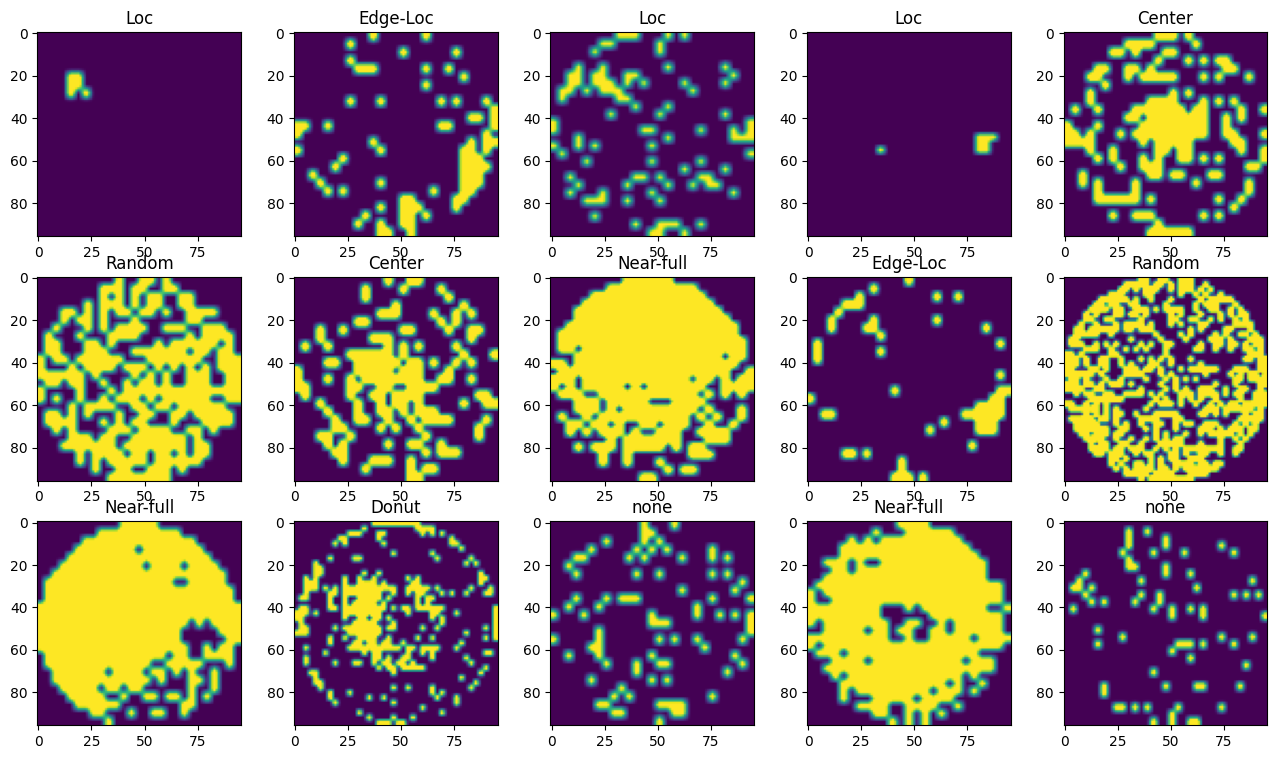

In [4]:
N_VIEW = 15
cols = min(N_VIEW, 5)
rows = (N_VIEW + cols - 1) // cols

_,axs = plt.subplots(rows,cols, figsize=(16,9))

ds = wm811k.dataset_single_defect()
for ax, (img, label) in zip(axs.flatten(), ds.take(N_VIEW)):
    ax.imshow(img)
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    ax.set_title(WM_811K.defect_from_int[i])
    

Center


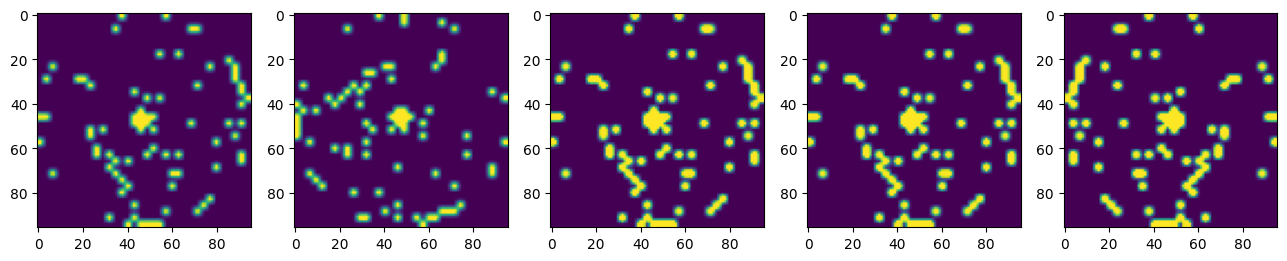

In [7]:
for img, label in ds.take(1):
    _, axs = plt.subplots(1,5, figsize=(16,4))
    axs[0].imshow(img)
    axs[1].imshow(wm811k.augment_image(img))
    axs[2].imshow(wm811k.augment_image(img))
    axs[3].imshow(wm811k.augment_image(img))
    axs[4].imshow(wm811k.augment_image(img))
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    print(WM_811K.defect_from_int[i])

## Multi Defect Tensorflow Dataset

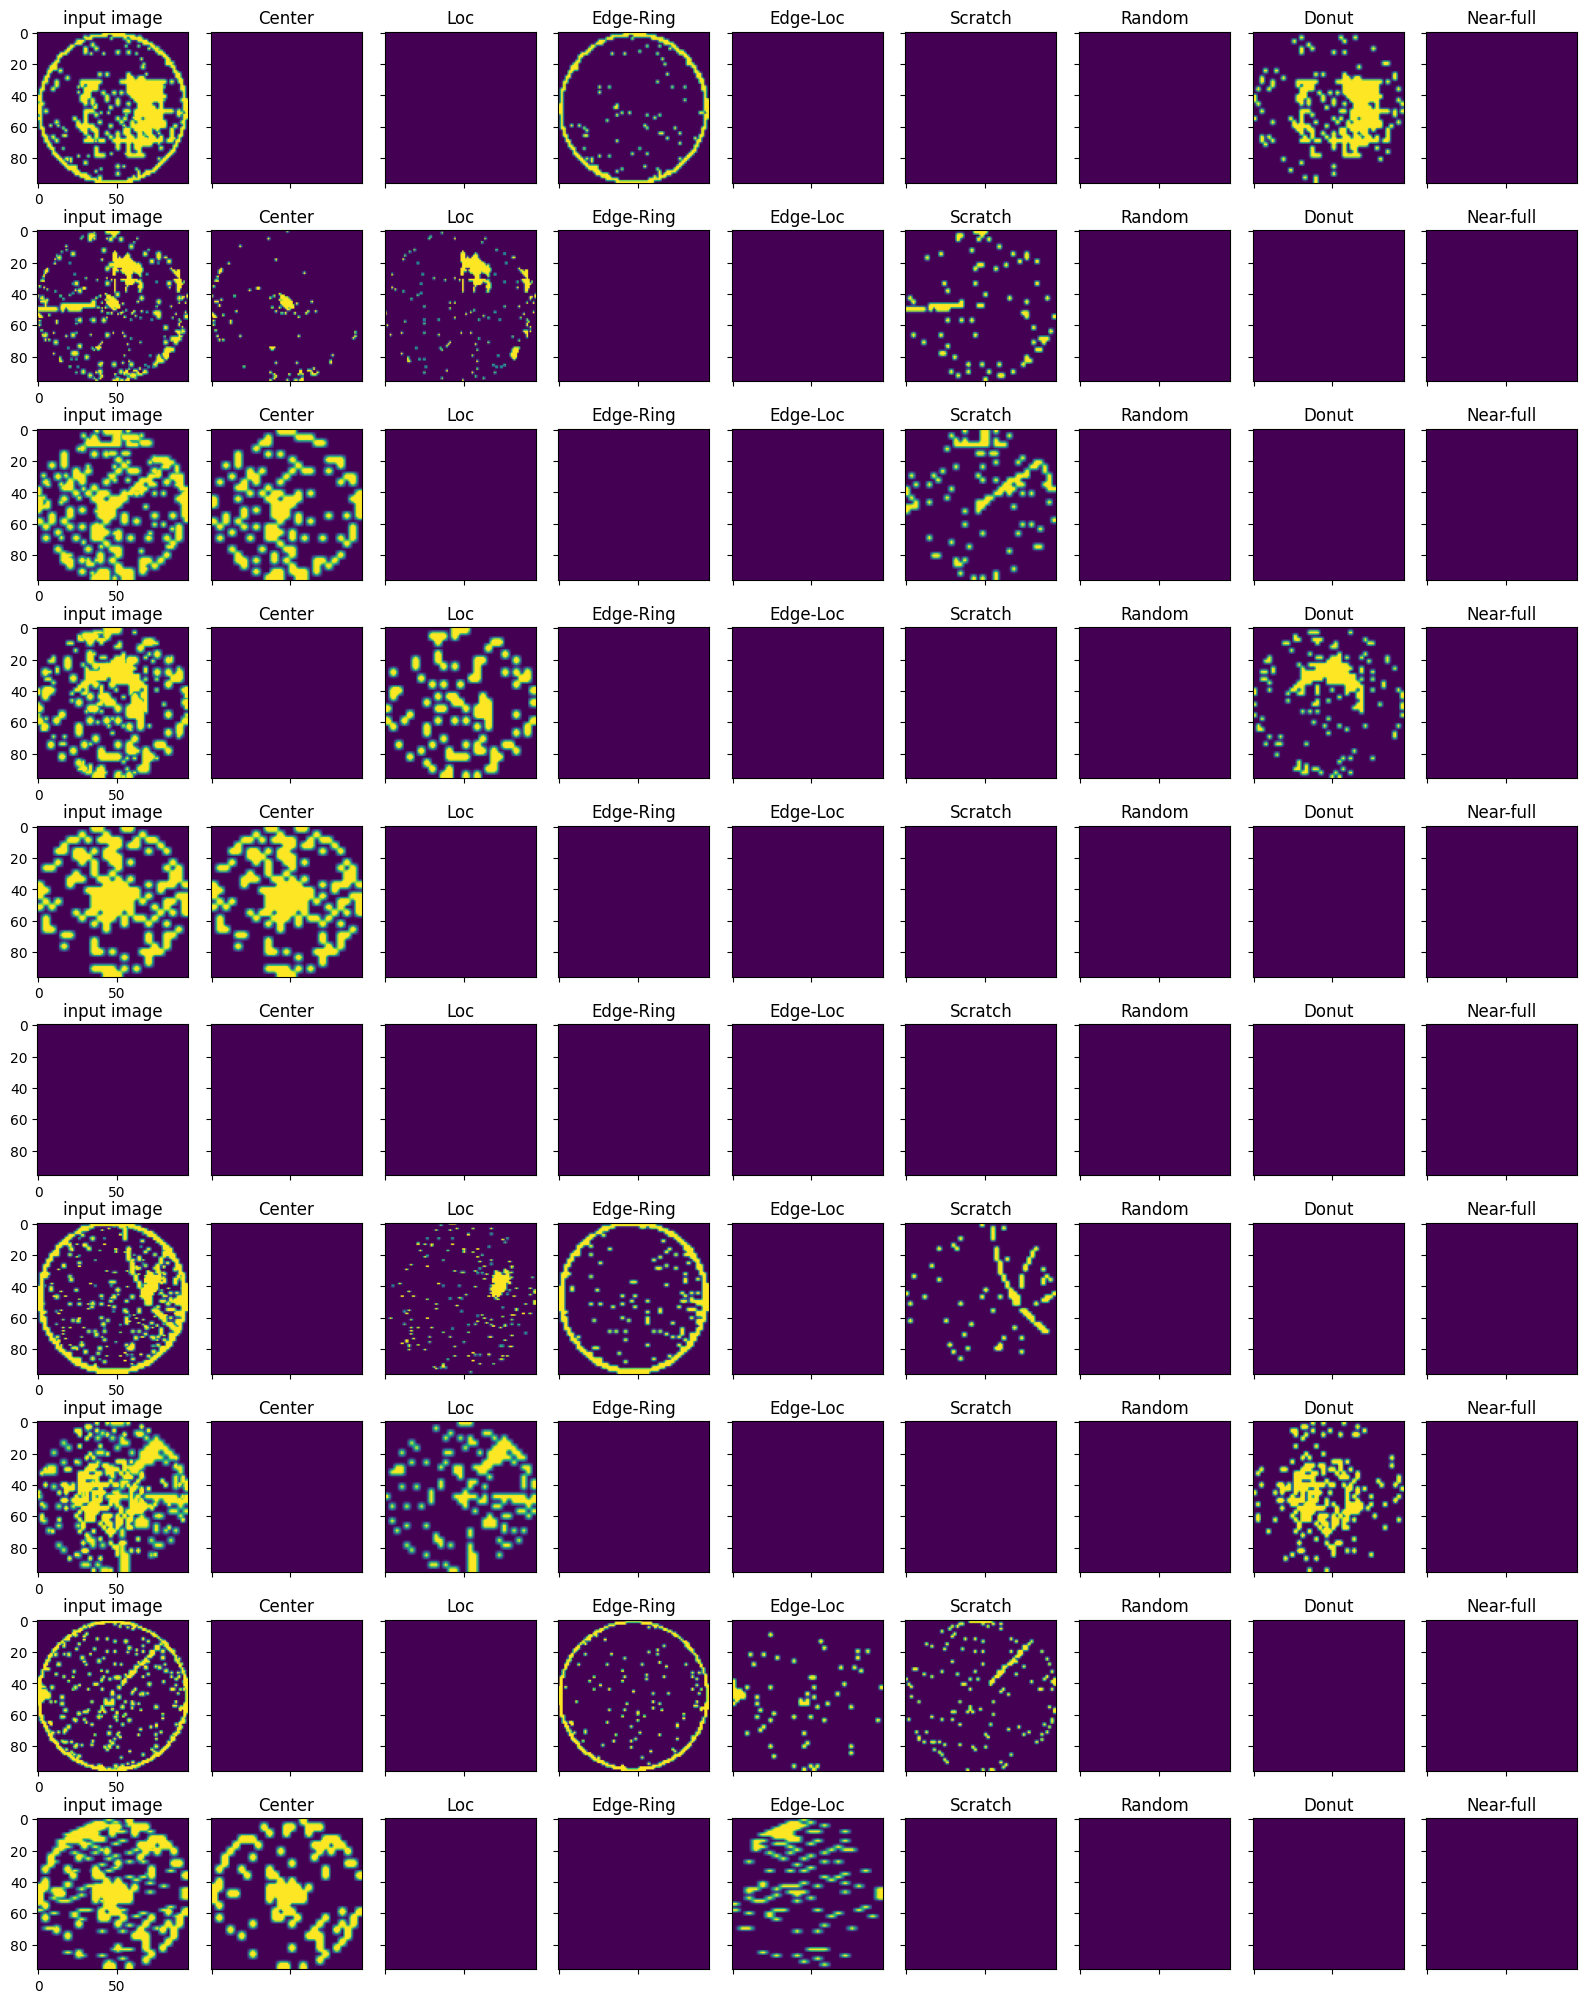

In [8]:
N_VIEW = 10
_,axs = plt.subplots(N_VIEW, 9, figsize=(16, 2*N_VIEW))

ds = wm811k.dataset_multi_defect_segmentation()
for row, (input_img, mid_stack) in enumerate(ds.take(N_VIEW)):
    axs[row,0].imshow(input_img)
    axs[row,0].set_title('input image')
    for col in range(8):
        axs[row,col+1].imshow(mid_stack[:,:,col])
        axs[row,col+1].set_title(WM_811K.defect_from_int[col])
        axs[row,col+1].set_xticklabels([])
        axs[row,col+1].set_yticklabels([])

plt.tight_layout()

## 1. Train Segmentation Model

In [ ]:
# create segmentation model with U-Net like architecture
def create_segmentation_model():
    def conv_block(x, f, pad='valid', halve=True):
        if halve:
            x = tf.keras.layers.MaxPooling2D((2,2))(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        return x

    def deconv_block(xA, xB, f, pad='valid', double=True):
        x = tf.keras.layers.Concatenate(axis=-1)([xA,xB])
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        if double:
            x = tf.keras.layers.Conv2DTranspose(f//2, (2,2), activation='relu', strides=(2,2))(x)
        return x

    img_input = tf.keras.layers.Input(shape=(*wm811k.imsize, 1))

    # encoder blocks
    x1 = conv_block(img_input, 32, 'same', False)
    x2 = conv_block(x1, 64)
    x3 = conv_block(x2, 128)
    x4 = conv_block(x3, 256)

    # dense block
    x5 = tf.keras.layers.GlobalAveragePooling2D()(x4)
    x5 = tf.keras.layers.Dense(256)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Reshape((1,1,256))(x5)
    x5 = tf.keras.layers.Conv2DTranspose(64, (5,5), activation='relu')(x5)

    # decoder blocks
    x6 = deconv_block(x4, x5, 128)
    x7 = deconv_block(x3, x6, 128)
    x8 = deconv_block(x2, x7, 64)
    x9 = deconv_block(x1, x8, 32, 'same', False)

    imgs_output = tf.keras.layers.Conv2D(WM_811K.n_classes-1, (3,3), activation='sigmoid', padding='same')(x9)
    return tf.keras.Model(inputs=img_input, outputs=imgs_output)


model_segmentation = create_segmentation_model()
model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)
model_segmentation.summary()

Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_303 (Conv2D) │ (None, 96, 96,    │        320 │ input_layer_38[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_304 (Conv2D) │ (None, 96, 96,    │      9,248 │ conv2d_303[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_215         │ (None, 96, 96,    │          0 │ conv2d_304[0][0]  │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ dropout_215[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_117   │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_305 (Conv2D) │ (None, 46, 46,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_306 (Conv2D) │ (None, 44, 44,    │     36,928 │ conv2d_305[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_216         │ (None, 44, 44,    │          0 │ conv2d_306[0][0]  │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        256 │ dropout_216[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_118   │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_307 (Conv2D) │ (None, 20, 20,    │     73,856 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_308 (Conv2D) │ (None, 18, 18,    │    147,584 │ conv2d_307[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_217         │ (None, 18, 18,    │          0 │ conv2d_308[0][0]  │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        512 │ dropout_217[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_119   │ (None, 9, 9, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_309 (Conv2D) │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_11

 Total params: 2,750,344 (10.49 MB)

 Trainable params: 2,748,680 (10.49 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [42]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [88]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_segmentation().batch(16).prefetch(tf.data.AUTOTUNE)

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2042
Epoch 1: loss improved from None to 0.14035, saving model to ../models/multi_defect_segmentation.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - loss: 0.1403
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0518
Epoch 2: loss improved from 0.14035 to 0.04506, saving model to ../models/multi_defect_segmentation.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - loss: 0.0451
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0350
Epoch 3: loss improved from 0.04506 to 0.03536, saving model to ../models/multi_defect_segmentation.keras

Epoch 3: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - loss: 0.0354
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0294
Epoch 4: loss improved from 0.03536 to 0.

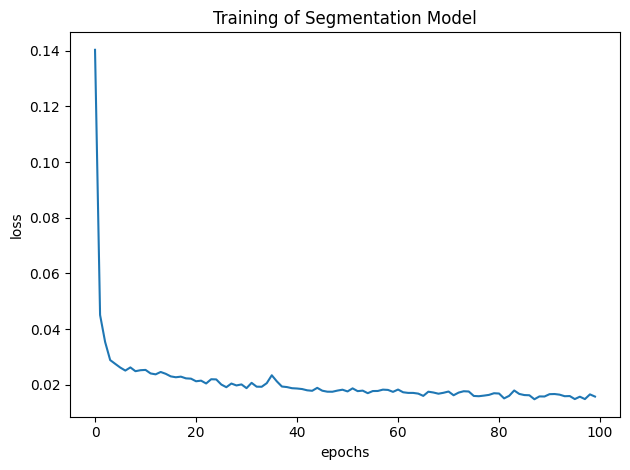

In [ ]:
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Training of Segmentation Model')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'segmentation_loss_curve.png'))

In [47]:
ds_train = wm811k.dataset_multi_defect_segmentation().batch(16).prefetch(tf.data.AUTOTUNE)

input_img_batch, output_imgs_batch = list(ds_train.take(1))[0]
pred_batch = model_segmentation.predict(input_img_batch)

2026-06-04 13:50:51.109013: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


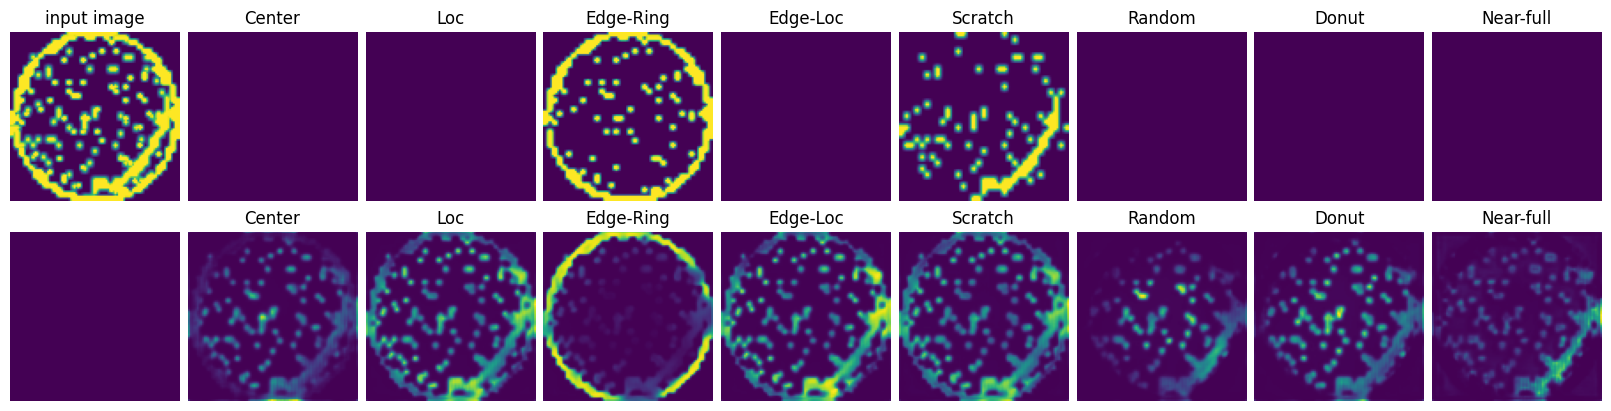

In [52]:
idx = 15
_,axs = plt.subplots(2,9, figsize=(16,4), layout='constrained')

axs[0,0].set_title('input image')
axs[0,0].imshow(input_img_batch[idx,:,:,0])
axs[1,0].imshow(np.zeros(wm811k.imsize))
for c in range(8):
    axs[0,c+1].set_title(WM_811K.defect_from_int[c])
    axs[0,c+1].imshow(output_imgs_batch[idx,:,:,c])
    axs[1,c+1].set_title(WM_811K.defect_from_int[c])
    axs[1,c+1].imshow(pred_batch[idx,:,:,c])

for ax in axs.flatten():
    ax.set_axis_off()

plt.savefig(os.path.join('..', 'plots', 'segmentation_sample.png'))

## 2. Pretrain Classification Model

In [143]:
# create classification model with traditional CNN architecture
def create_classification_model():
    def conv_block(x, f, pad='valid', halve=True):
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        if halve:
            x = tf.keras.layers.MaxPooling2D((2,2))(x)
        return x

    seg_input = tf.keras.layers.Input(shape=(*wm811k.imsize, wm811k.n_classes-1))

    # convolution blocks
    x = conv_block(seg_input, 32, 'same')
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256, halve=False)

    # flatten + dense
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid')(x)

    return tf.keras.Model(inputs=seg_input, outputs=x)


model_classification = create_classification_model()
model_classification.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model_classification.summary()

Model: "functional_91"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_52 (InputLayer)     │ (None, 96, 96, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_392 (Conv2D)             │ (None, 96, 96, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_393 (Conv2D)             │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_281 (Dropout)           │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_251         │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_152               │ (None, 48, 48, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_394 (Conv2D)             │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_395 (Conv2D)             │ (None, 44, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_282 (Dropout)           │ (None, 44, 44, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_252         │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_153               │ (None, 22, 22, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_396 (Conv2D)             │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_397 (Conv2D)             │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_283 (Dropout)           │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_253         │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_154               │ (None, 9, 9, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_398 (Conv2D)             │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_399 (Conv2D)             │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_284 (Dropout)           │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_254         │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_40     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 2,504,776 (9.55 MB)

 Trainable params: 2,499,720 (9.54 MB)

 Non-trainable params: 5,056 (19.75 KB)

In [144]:
model_segmentation.name = 'segmentation'
model_classification.name = 'classification'
model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification
], name='fullstack')

# freeze segmentation model
model_fullstack.layers[0].trainable = False

model_fullstack.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model_fullstack.summary()

Model: "fullstack"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ segmentation (Functional)       │ (None, 96, 96, 8)      │     2,750,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Functional)     │ (None, 8)              │     2,504,776 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,255,120 (20.05 MB)

 Trainable params: 2,499,720 (9.54 MB)

 Non-trainable params: 2,755,400 (10.51 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_fullstack().batch(16).prefetch(tf.data.AUTOTUNE)

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.6694 - loss: 0.7744
Epoch 1: loss improved from None to 0.72199, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - auc: 0.7330 - loss: 0.7220
Restoring model weights from the end of the best epoch: 1.


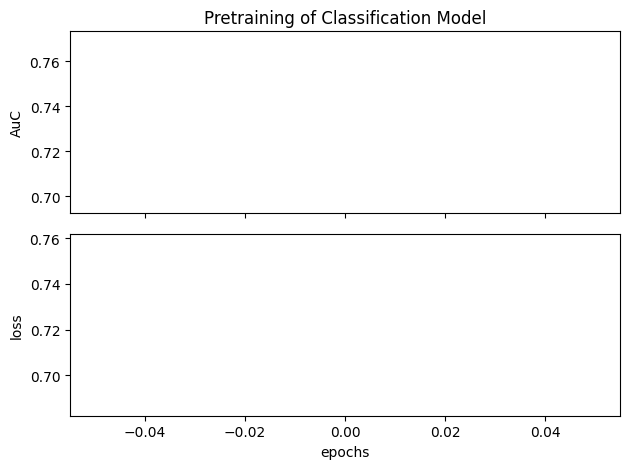

In [139]:
_,(ax1,ax2) = plt.subplots(2,1, sharex=True)
ax1.plot(history.history['auc'])
ax1.set_ylabel('AuC')
ax1.set_title('Pretraining of Classification Model')
ax2.plot(history.history['loss'])
ax2.set_xlabel('epochs')
ax2.set_ylabel('loss')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'classification_pretrain_loss_curve.png'))

## 3. Fine-Tune Full Stack Model

In [145]:
# unfreeze segmentation model
model_fullstack.layers[0].trainable = True

model_fullstack.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model_fullstack.summary()

Model: "fullstack"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ segmentation (Functional)       │ (None, 96, 96, 8)      │     2,750,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Functional)     │ (None, 8)              │     2,504,776 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,255,120 (20.05 MB)

 Trainable params: 5,248,400 (20.02 MB)

 Non-trainable params: 6,720 (26.25 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_fullstack().batch(16).prefetch(tf.data.AUTOTUNE)

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.3379 - loss: 4.4229
Epoch 1: val_loss improved from None to 2.66255, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 99s 771ms/step - accuracy: 0.3423 - loss: 4.5206 - val_accuracy: 0.3555 - val_loss: 2.6625
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.3599 - loss: 4.5912
Epoch 2: val_loss did not improve from 2.66255
128/128 ━━━━━━━━━━━━━━━━━━━━ 86s 674ms/step - accuracy: 0.3560 - loss: 4.5533 - val_accuracy: 0.2988 - val_loss: 2.8659
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3665 - loss: 4.5748
Epoch 3: val_loss did not improve from 2.66255
128/128 ━━━━━━━━━━━━━━━━━━━━ 78s 615ms/step - accuracy: 0.3569 - loss: 4.6785 - val_accuracy: 0.3008 - val_loss: 2.8108
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.3400 - loss: 4.6825
Epoch 4: val

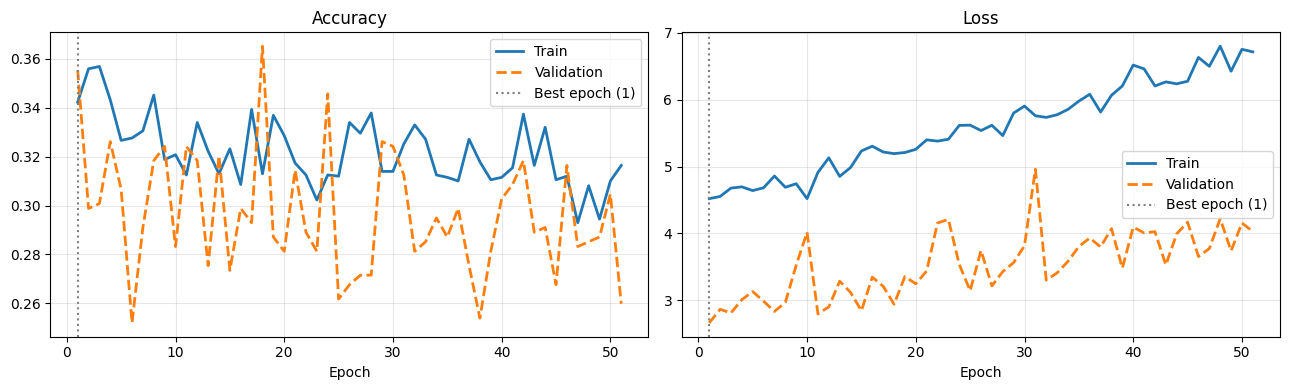

Saved ./performance_plots/training_curves.png


In [ ]:
_,(ax1,ax2) = plt.subplots(2,1, sharex=True)
ax1.plot(history.history['auc'])
ax1.set_ylabel('AuC')
ax1.set_title('Training of Fullstack Model')
ax2.plot(history.history['loss'])
ax2.set_xlabel('epochs')
ax2.set_ylabel('loss')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'fullstack_loss_curve.png'))